---
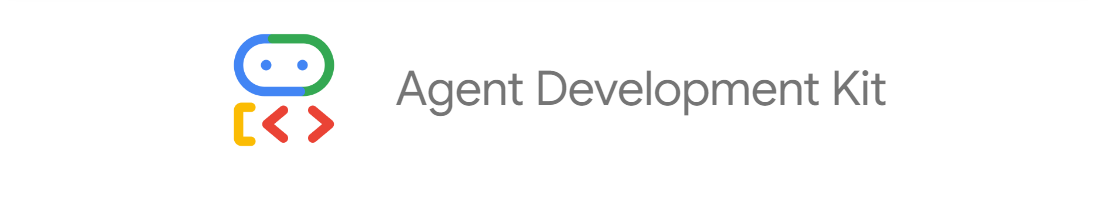

---

# Structured Output in ADK
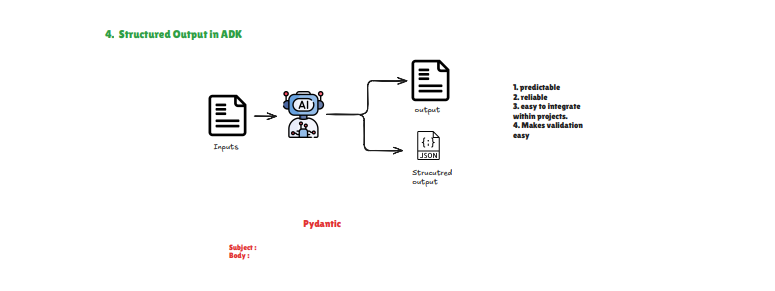

## LLM agents 👉 [Click Here](https://google.github.io/adk-docs/agents/llm-agents/#defining-the-agents-identity-and-purpose)
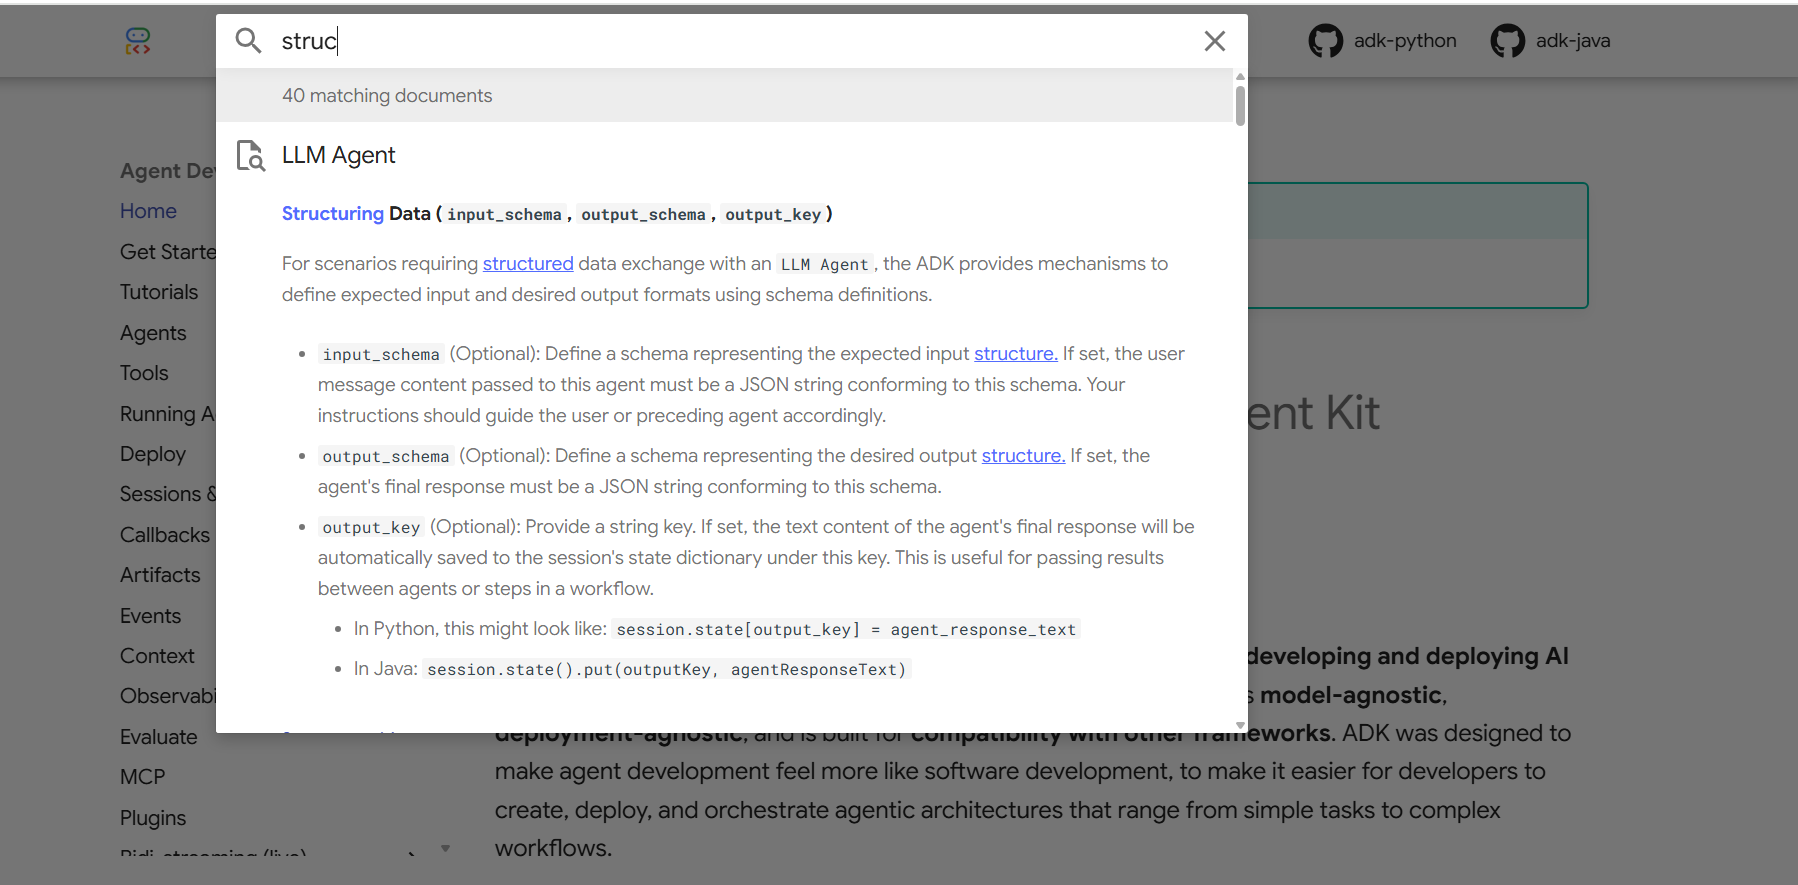 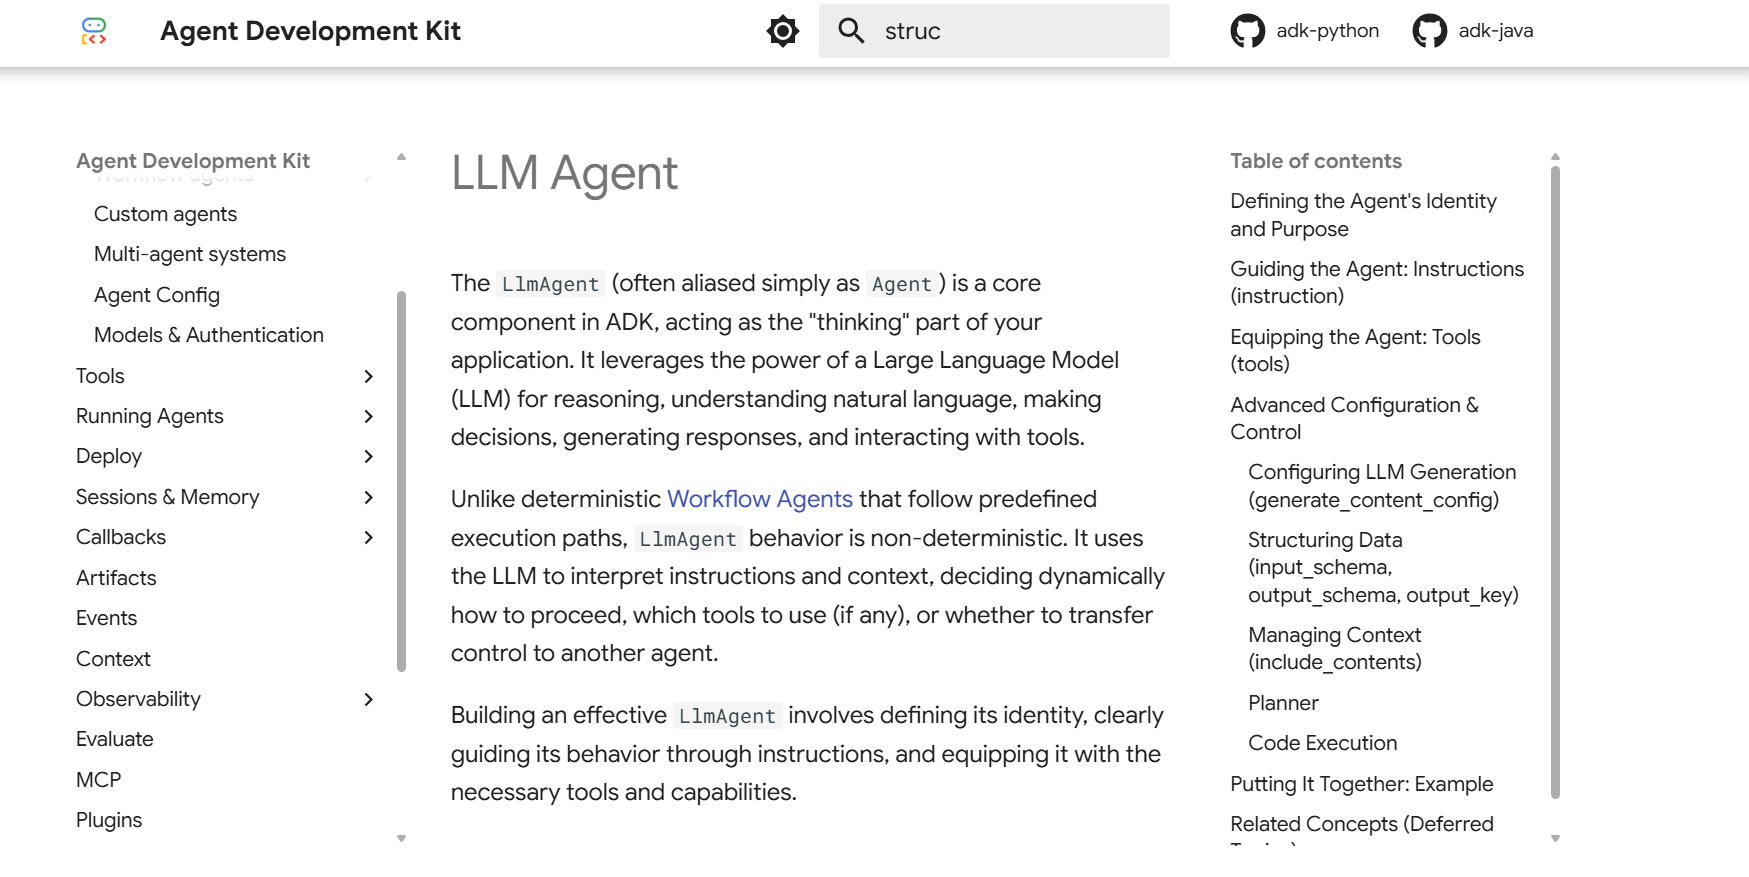 ![image-5.png] (attachment:image-5.png) 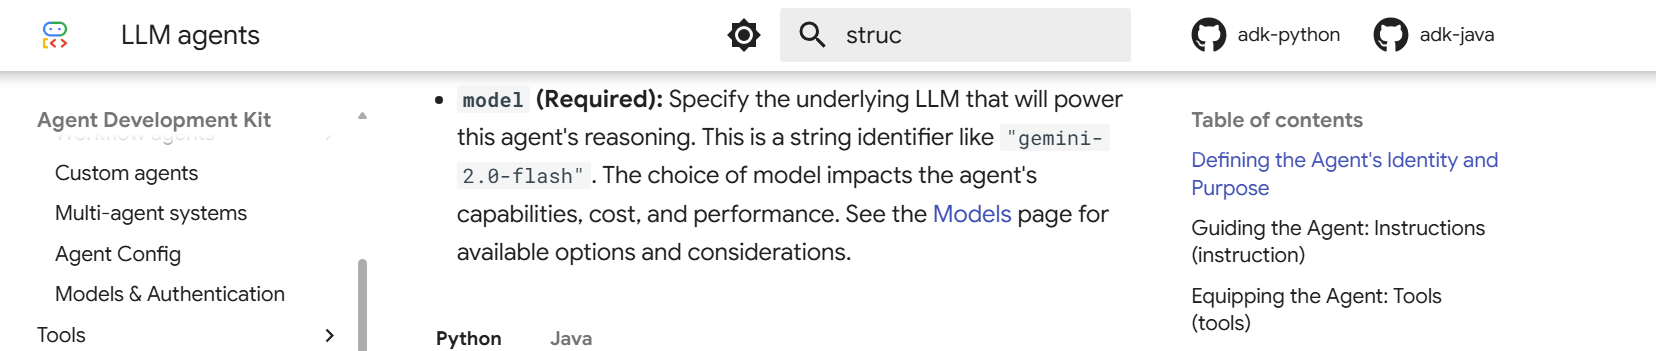 

```Python
# Example: Defining the basic identity
capital_agent = LlmAgent(
    model="gemini-2.0-flash",
    name="capital_agent",
    description="Answers user questions about the capital city of a given country."
    # instruction and tools will be added next
)
```
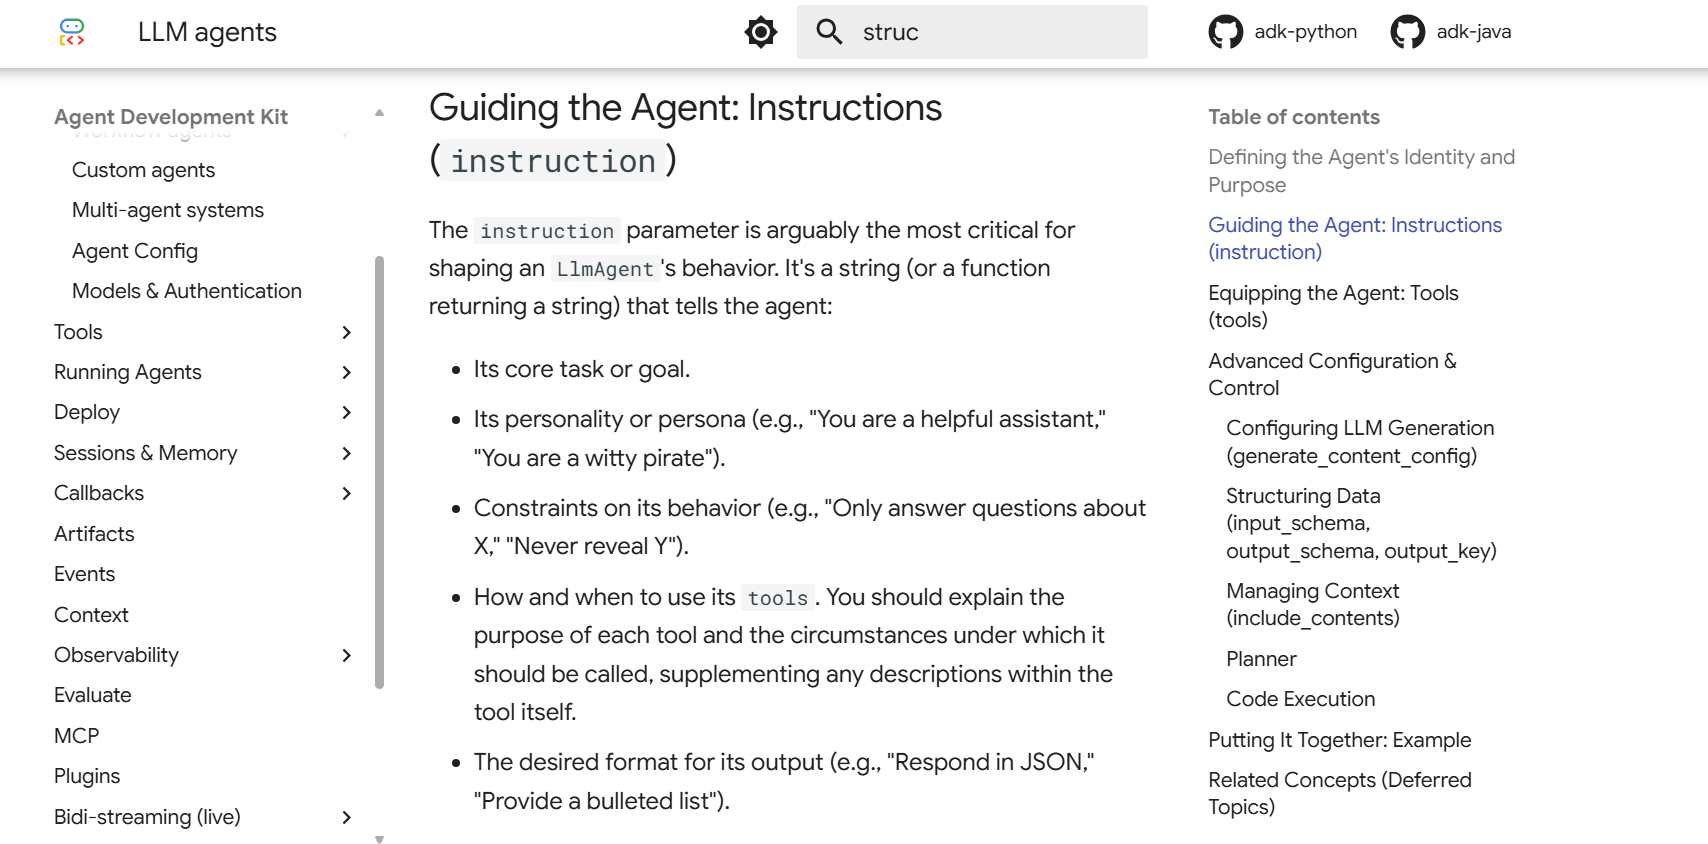 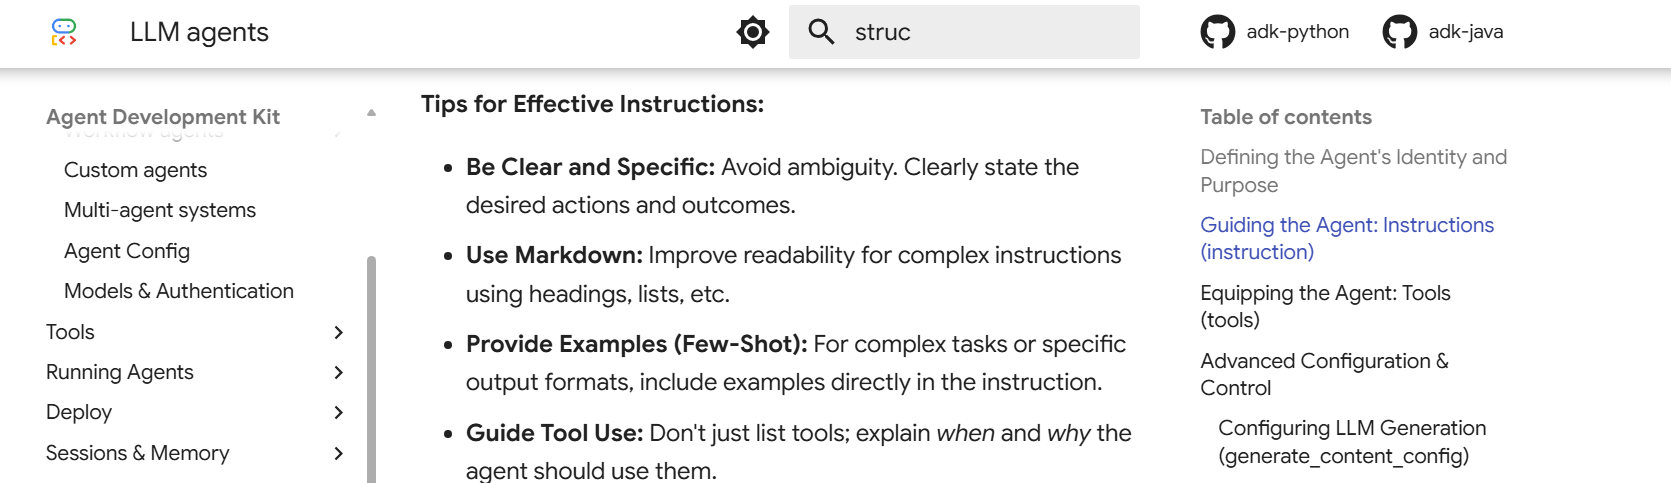 ![image-8.png] (attachment:image-8.png) 

```Python
# Example: Adding instructions
capital_agent = LlmAgent(
    model="gemini-2.0-flash",
    name="capital_agent",
    description="Answers user questions about the capital city of a given country.",
    instruction="""You are an agent that provides the capital city of a country.
When a user asks for the capital of a country:
1. Identify the country name from the user's query.
2. Use the `get_capital_city` tool to find the capital.
3. Respond clearly to the user, stating the capital city.
Example Query: "What's the capital of {country}?"
Example Response: "The capital of France is Paris."
""",
    # tools will be added next
)
```

### Structuring Data (input_schema, output_schema, output_key) 👉 [Click Here](https://google.github.io/adk-docs/agents/llm-agents/#structuring-data-input_schema-output_schema-output_key)
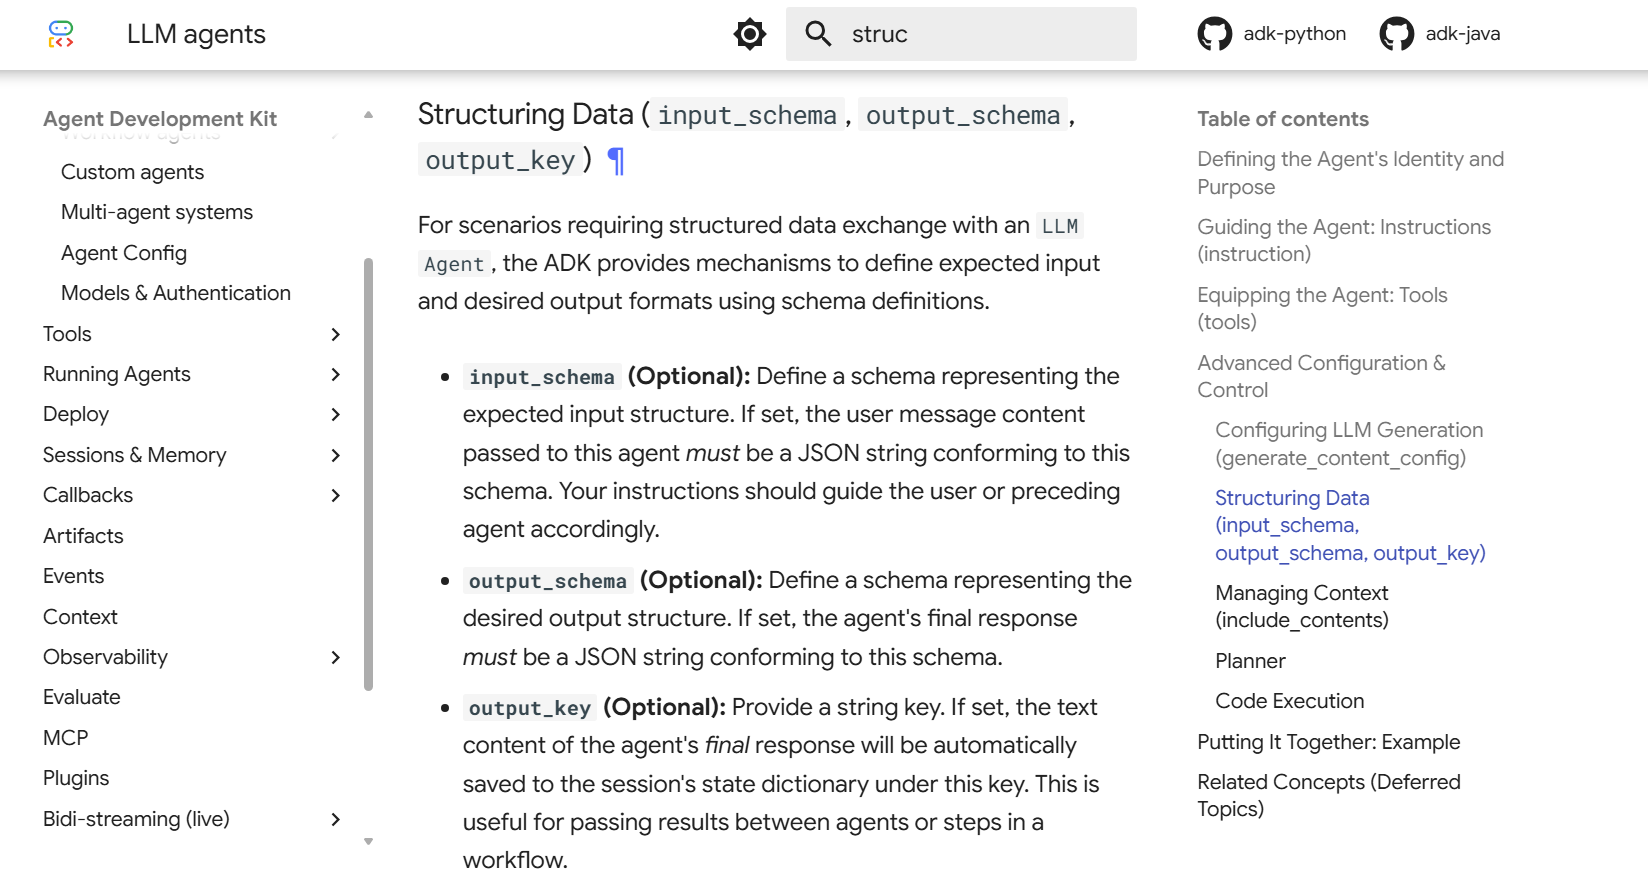 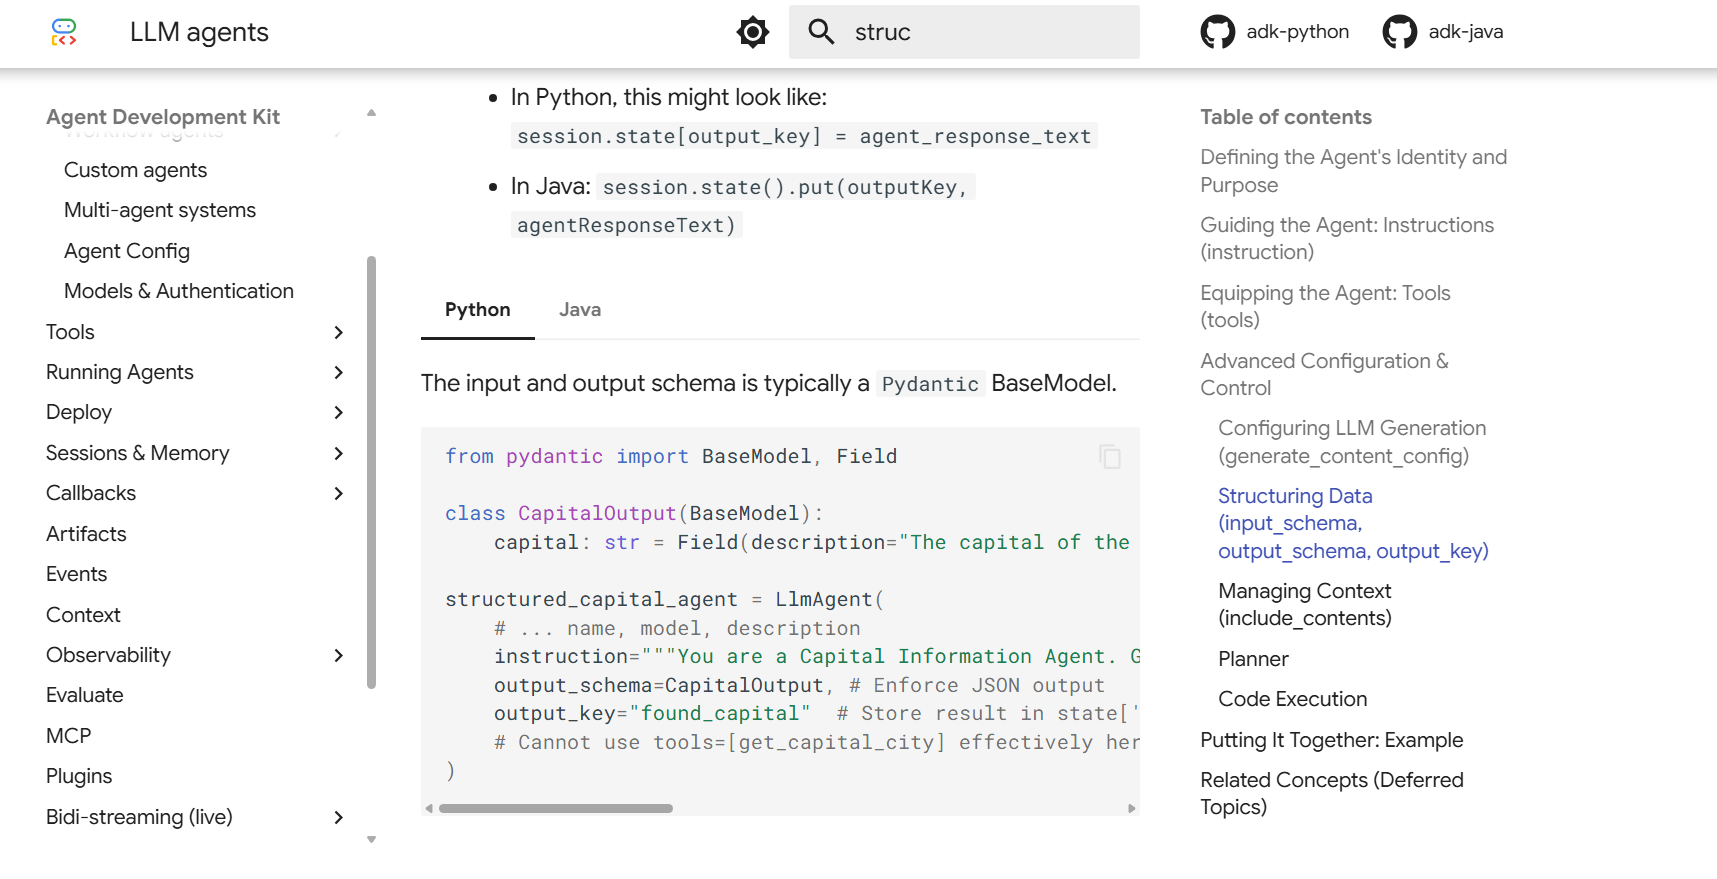

```Python
from pydantic import BaseModel, Field

class CapitalOutput(BaseModel):
    capital: str = Field(description="The capital of the country.")

structured_capital_agent = LlmAgent(
    # ... name, model, description
    instruction="""You are a Capital Information Agent. Given a country, respond ONLY with a JSON object containing the capital. Format: {"capital": "capital_name"}""",
    output_schema=CapitalOutput, # Enforce JSON output
    output_key="found_capital"  # Store result in state['found_capital']
    # Cannot use tools=[get_capital_city] effectively here
)
```

---